# Write one kernel. Run a million. Train it with PyTorch.

A ball thrown with air drag. Four short steps: write the physics for **one**
sample, run it for a million, get its derivatives for free, then hand it to
PyTorch to learn the drag coefficient from noisy landings.

**Time:** about 10 minutes · **Runs on:** CPU (and the GPU, if one is visible) ·
**You need:** eagle, hawk, torch and matplotlib (see Install below).


## Install

Skips the install if `eagle`, `hawk`, `torch` and `matplotlib` already import (e.g. an
environment you set up yourself). Otherwise install the family from PyPI.
The NVIDIA packages come only through the `[cuda12]` / `[cuda13]` extras (pick the one matching
`nvidia-smi`); to build from source instead, see
[Building from source](https://amasat01.github.io/build_from_source.html).

In [1]:
# !pip install "raptor-hawk[cuda12]" "raptor-eagle[cuda12]" torch matplotlib
try:
    import eagle, hawk, torch, matplotlib  # noqa: F401
except ImportError as err:
    raise ImportError(
        "eagle, hawk, torch and matplotlib are needed; install them with pip (see the line above), "
        "see https://amasat01.github.io/build_from_source.html"
    ) from err


## Device switch

Same line on every RAPTOR tutorial.

In [2]:
import numpy as np

try:
    import cupy as cp
    DEVICE = "gpu" if cp.cuda.runtime.getDeviceCount() > 0 else "cpu"
except Exception:
    DEVICE = "cpu"
xp = cp if DEVICE == "gpu" else np
print("running on", DEVICE)


running on cpu


## 1. Write one sample's kernel

A hawk kernel is a plain Python function: it reads the planes it declares and
writes the ones it owns. `r`/`v` are this ball's position and velocity —
`Mutable`, because the kernel updates them. Read one like any local variable
(you get the value from when this launch began, until the kernel itself
assigns a new one); write the result back by assigning to the same name.
`cd` is the drag coefficient, one `Scalar` per sample; `dt`/`g` are `Param`s,
one value shared by everyone. `terminated = ...` is the stop rule: once a
ball's height goes below zero, it's done.

One call, `eagle.simulate`, runs it: pass the kernel's arguments as you
would call it, plain floats in, one throw out.

In [3]:
import hawk
from hawk import Mutable, Param, Scalar, Terminated, Vector
from hawk.math import norm, vec
import eagle


@hawk.kernel
def flight(cd: Scalar, dt: Param, g: Param, terminated: Terminated,
           r: Mutable[Vector[3]], v: Mutable[Vector[3]]):
    a = vec(0.0, 0.0, -g) - cd * norm(v) * v
    v = v + dt * a
    r = r + dt * v
    terminated = r[2] < 0


one = eagle.simulate(
    flight,
    cd=0.004, dt=0.01, g=9.81,
    r=xp.array([0.0, 0.0, 1.0]), v=xp.array([20.0, 0.0, 15.0]),
    max_steps=2000,
)
print(one.status, one.steps, one.r)

finished 320 [53.08994129  0.         -0.05716388]


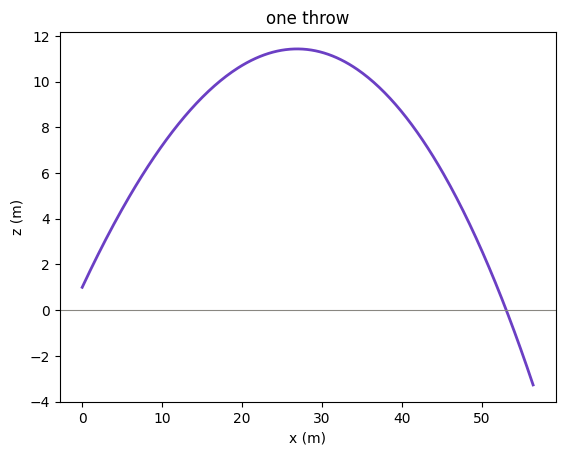

In [4]:
# The picture: replay the same throw one step at a time to plot its arc
# (eagle.simulate itself only hands back the final state). eagle.simulate
# writes its Mutable arguments, so each step's position is copied out
# before the next call overwrites it.
import matplotlib.pyplot as plt

path = [np.array([0.0, 0.0, 1.0])]
r, v = xp.array([0.0, 0.0, 1.0]), xp.array([20.0, 0.0, 15.0])
for _ in range(one.steps):
    step = eagle.simulate(flight, cd=0.004, dt=0.01, g=9.81, r=r, v=v, max_steps=1)
    r, v = step.r, step.v
    path.append(np.array(r, copy=True))
path = np.array(path)

plt.plot(path[:, 0], path[:, 2], color="#6b3fc4", lw=2)
plt.axhline(0, color="#898781", lw=0.8)
plt.xlabel("x (m)"); plt.ylabel("z (m)"); plt.title("one throw")
plt.show()

**What just happened:**
- `flight` is one sample's physics: gravity plus quadratic drag, a
  semi-implicit Euler step.
- `terminated` marked this sample done at step 320, the step its height
  first went below zero — `eagle.simulate` stopped there instead of running
  to `max_steps`.
- `one.r` is the landing position: about 53 m downrange.

## 2. Run a lot of them

The same call: give an array where each sample has its own value —
`cd` now needs one value per sample too. CPU defaults to 100,000 throws
so this cell stays fast without a GPU; set `n = 1_000_000` once
`DEVICE == "gpu"`.

100,000 / 100,000 finished, 8 launches, 31.0 ms (on the machine that built this page)


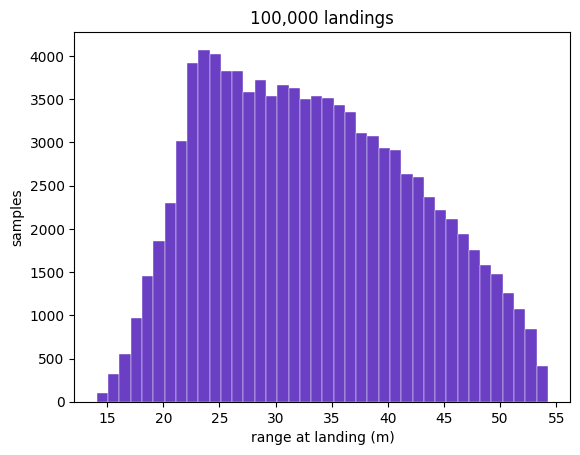

In [5]:
n = 100_000 if DEVICE == "cpu" else 1_000_000  # CPU: kept smaller to stay fast

rng = np.random.default_rng(0)
r0 = xp.zeros((3, n))
r0[2] = 1.0
speed = 15.0 + 10.0 * rng.random(n)
elevation = np.radians(20.0) + np.radians(50.0) * rng.random(n)
heading = 2 * np.pi * rng.random(n)
v0 = xp.stack([
    speed * np.cos(elevation) * np.cos(heading),
    speed * np.cos(elevation) * np.sin(heading),
    speed * np.sin(elevation),
])

many = eagle.simulate(
    flight,
    cd=xp.full(n, 0.004), dt=0.01, g=9.81, r=r0, v=v0,
    max_steps=2000,
)
print(f"{many.finished.sum():,} / {n:,} finished, {many.report.launches} launches, "
      f"{many.wall_s * 1e3:.1f} ms (on the machine that built this page)")

import matplotlib.pyplot as plt

ranges = np.hypot(np.asarray(many.r[0]), np.asarray(many.r[1]))
plt.hist(ranges, bins=40, color="#6b3fc4", edgecolor="white", linewidth=0.3)
plt.xlabel("range at landing (m)")
plt.ylabel("samples")
plt.title(f"{n:,} landings")
plt.show()

**What just happened:**
- Every sample ran the same kernel; each stopped on its own step, and the
  finished ones stopped costing launches.
- 100,000 throws took 8 launches, not 100,000 — launches are batched, not
  one per sample or one per step.
- The histogram is this run's own throws: a spread of ranges from a spread
  of speeds and angles.

## 3. Get derivatives

`eagle.frameworks.torch.function` wraps a kernel as a `torch.autograd.Function`:
forward runs the kernel, backward runs the **derived** reverse-mode kernel —
nothing is taped. This cell uses `flight_step`, the one-step kernel from
eagle's own [torch training tutorial](https://amasat01.github.io/eagle/content/userguide/tutorials/03_torch_training.html)
(separate in and next-state planes, the shape `torch.autograd.Function` wants).
`torch.autograd.gradcheck` compares it against finite differences.

In [6]:
from hawk import Vector
from eagle.frameworks import torch as eagle_torch


@hawk.kernel
def flight_step(
    r: Vector[3], v: Vector[3], cd: Scalar, dt: Param, g: Param,
    terminated: Terminated, r_next: Mutable[Vector[3]], v_next: Mutable[Vector[3]],
):
    a = vec(0.0, 0.0, -g) - cd * norm(v) * v
    v_next = v + dt * a
    r_next = r + dt * v_next


step = eagle_torch.function(flight_step, wrt=("r", "v", "cd"))

m = 8
r = torch.randn(3, m, dtype=torch.float64, requires_grad=True)
v = torch.randn(3, m, dtype=torch.float64, requires_grad=True)
cd = torch.rand(m, dtype=torch.float64, requires_grad=True)
landed = torch.zeros(m, dtype=torch.bool)
landed[[2, 5]] = True  # two of the eight samples already landed

ok = torch.autograd.gradcheck(
    lambda r, v, cd: step(r, v, cd, 0.05, 9.81, landed),
    (r, v, cd), check_forward_ad=True, check_batched_grad=False,
)
print("gradcheck:", ok)

gradcheck: True


**What just happened:**
- `step` is `flight_step`'s derived reverse- *and* forward-mode kernel,
  compiled the first time it ran.
- `gradcheck` matches both against finite differences: `True`.
- The two landed samples (`landed[[2, 5]]`) get exactly zero gradient — a
  terminated sample never corrects a later step.

## 4. Hand it to PyTorch

`many.r` from step 2 is a plain NumPy array (CPU) or a CuPy one (GPU). The
cells below cross it into torch, build a tiny model around `step` from
step 3, and fit the drag coefficient to noisy "observed" landings.

**Cross it into torch.** `torch.from_dlpack` crosses an array into torch
without copying it, when the backing memory supports that.

In [7]:
landed_torch = torch.from_dlpack(many.r)
same_memory = np.shares_memory(np.asarray(many.r), landed_torch.numpy())
print("torch.from_dlpack(many.r) shares memory on this machine:", same_memory)

torch.from_dlpack(many.r) shares memory on this machine: True


A CUDA array crossing this way is raptor's certified `T-IN-CUDA-ALIAS` row
— always zero-copy; a plain NumPy one isn't a certified crossing at all, so
this cell *checks* rather than assumes it.

**Build a tiny model around `step`.** `Ballistic` unrolls `step` from
step 3 over a flight. Its one learned value is `log(cd)`, not `cd` itself,
so training can never push the drag coefficient negative.

In [8]:
import math

DT, G, STEPS = 0.05, 9.81, 80


class Ballistic(torch.nn.Module):
    def __init__(self, cd_guess):
        super().__init__()
        self.log_cd = torch.nn.Parameter(
            torch.tensor(math.log(cd_guess), dtype=torch.float64))

    def forward(self, r0, v0):
        cd = self.log_cd.exp().expand(r0.shape[-1]).contiguous()
        r, v = r0, v0
        for _ in range(STEPS):
            is_landed = r[2] < 0.0
            r_next, v_next = step(r, v, cd, DT, G, is_landed)
            r = torch.where(is_landed, r, r_next)
            v = torch.where(is_landed, v, v_next)
        return r

**Make up something to fit.** Run `Ballistic` with the true drag
coefficient to get a batch of clean landings, then add a little noise —
that noisy batch is what the model has to explain.

In [9]:
torch.manual_seed(0)
N, CD_TRUE = 128, 0.004
speed_t = 20.0 + 20.0 * torch.rand(N, dtype=torch.float64)
elevation_t = (math.radians(20.0)
              + math.radians(50.0) * torch.rand(N, dtype=torch.float64))
heading_t = 2.0 * math.pi * torch.rand(N, dtype=torch.float64)
v0_t = torch.stack([
    speed_t * elevation_t.cos() * heading_t.cos(),
    speed_t * elevation_t.cos() * heading_t.sin(),
    speed_t * elevation_t.sin(),
])
r0_t = torch.zeros(3, N, dtype=torch.float64)
r0_t[2] = 1.0

with torch.no_grad():
    truth = Ballistic(CD_TRUE)(r0_t, v0_t)
observed = truth + 0.02 * torch.randn(truth.shape, dtype=torch.float64)
print(f"{N} synthetic throws, true cd = {CD_TRUE} /m")

128 synthetic throws, true cd = 0.004 /m


**Train it.** The same story as eagle's own torch tutorial, starting from
a guess five times too large, fit with `torch.optim.LBFGS`:

step 0: loss 0.000433 m^2, cd 0.003999 /m
step 1: loss 0.000433 m^2, cd 0.003999 /m
step 2: loss 0.000433 m^2, cd 0.003999 /m


step 3: loss 0.000433 m^2, cd 0.003999 /m
learned cd = 0.003999 /m (true 0.004 /m)


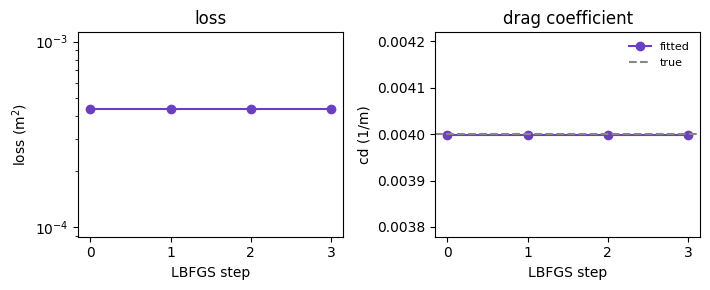

In [10]:
model = Ballistic(cd_guess=0.02)
optimizer = torch.optim.LBFGS(
    model.parameters(), max_iter=20, line_search_fn="strong_wolfe")
losses, cds = [], []


def closure():
    optimizer.zero_grad()
    loss = ((model(r0_t, v0_t) - observed) ** 2).mean()
    loss.backward()
    return loss


for epoch in range(4):
    optimizer.step(closure)
    with torch.no_grad():
        loss = ((model(r0_t, v0_t) - observed) ** 2).mean()
    losses.append(loss.item())
    cds.append(model.log_cd.exp().item())
    print(f"step {epoch}: loss {loss.item():.6f} m^2, cd {cds[-1]:.6f} /m")

print(f"learned cd = {cds[-1]:.6f} /m (true {CD_TRUE} /m)")

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0))
axes[0].plot(losses, "o-", color="#6b3fc4")
axes[0].set_yscale("log")
axes[0].set_xlabel("LBFGS step")
axes[0].set_ylabel("loss (m$^2$)")
axes[0].set_title("loss")
axes[1].plot(cds, "o-", color="#6b3fc4", label="fitted")
axes[1].axhline(CD_TRUE, color="#898781", ls="--", label="true")
axes[1].set_xlabel("LBFGS step")
axes[1].set_ylabel("cd (1/m)")
axes[1].set_title("drag coefficient")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

**What just happened:**
- `step`'s derived gradient (from step 3) is what `loss.backward()` used
  to update `log_cd` — no finite differences in the training loop.
- L-BFGS found the true drag coefficient, 0.004 /m, from noisy landings in
  a handful of evaluations.
- The DLPack crossing a few cells up was zero-copy here, but that's this
  machine, not a promise — raptor certifies the CUDA crossing, not this
  CPU one.

**One loose end.** Inside `Ballistic.forward`, each step works out
`is_landed = r[2] < 0.0` by hand and uses `torch.where` to freeze a landed
sample's state — the same idea as `terminated` from step 1, just worked
out again here because `step()` hands back the next position and velocity
but not its own stop decision. A later version of `step()` may return
that decision directly, so the loop could reuse it instead of
recomputing it.